Fução Borradez

In [ ]:
import cv2
import numpy as np
from PIL import Image

# calcular_fator_borradez(data_or_path)
# - Entrada: caminho para imagem (str) ou array NumPy (RGB ou grayscale).
# - Saída: float representando o "fator de borradez" calculado (maior = mais borrada),
#          ou None em caso de erro/arquivo inválido.
#
# Passos principais:
# 1) Ler a imagem (cv2 preferencialmente; fallback para PIL para WebP/formatos especiais).
# 2) Converter para grayscale caso necessário e normalizar para [0,1].
# 3) Subtrair a média para remover componente DC (evita pico dominante).
# 4) Calcular FFT 2D -> espectro de potência e mover as frequências mais altas para o centro ((0,0) -> centro da imagem)).
# 5) Define o retângulo central e faz o recorte do centro da imagem
# 6) Retornar o fator de borradez, que é o inverso da média das frequências.
#
# Referência: https://www.geeksforgeeks.org/computer-vision/fast-fourier-transform-in-image-processing/

# calcular_borradez_laplaciano(data_or_path)
# - Entrada: caminho para imagem (str) ou array NumPy (RGB ou grayscale).
# - Saída: float representando o "fator de borradez" calculado (maior = mais borrada),
#          ou None em caso de erro/arquivo inválido.
#
# Passos principais:
# 1) Ler a imagem (cv2 preferencialmente; fallback para PIL para WebP/formatos especiais).
# 2) Aplica o Laplaciano e calcula a variância
# 3) Retorna o valor de maneira MUITO mais rápida que a fft, mas com resultados similares

def calcular_fator_borradez(data_or_path):
    """Calcula um indicador numérico de borradez da imagem."""
    img = None

    # Se foi passado um caminho, tenta abrir com cv2; se falhar, tenta com PIL
    if isinstance(data_or_path, str):
        img = cv2.imread(data_or_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            try:
                # PIL suporta .webp e outros formatos menos comuns
                pil = Image.open(data_or_path).convert('L')
                img = np.array(pil)
            except Exception:
                return None
    else:
        # Se recebeu um array (ex.: imagem já carregada), garante formato adequado
        arr = np.asarray(data_or_path)
        if arr.ndim == 3:
            # Converte RGB/BGR para grayscale
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)
        img = arr

    if img is None:
        return None

    # Converter para float e normalizar
    img = img.astype(np.float32)
    img = img / 255.0
    img_normalizada = img - np.mean(img)

    # FFT 2D
    f = np.fft.fft2(img_normalizada)
    fshift = np.fft.fftshift(f)

    # Define o retangulo central (miolo) da imagem no domínio da frequência
    altura, largura = img.shape
    centro_x, centro_y = largura // 2, altura // 2

    # Tamanho do retângulo central
    porcentagem_corte = 0.15
    altura_centro = int(altura * porcentagem_corte)
    largura_centro = int(largura * porcentagem_corte)

    # Coordenadas do retângulo central
    x_min = centro_x - (largura_centro // 2)
    x_max = centro_x + (largura_centro // 2)
    y_min = centro_y - (altura_centro // 2)
    y_max = centro_y + (altura_centro // 2)

    # Realiza o corte da imagem
    f_cortado = fshift[y_min:y_max, x_min:x_max]


    # Calcula a magnetude do que sobrou (apenas as altas frequências)
    espectro_magnetude = np.abs(f_cortado)

    # Energia total das altas frequências. Imagens nítidas terão valores altos aqui
    energia_alta_freq = np.mean(espectro_magnetude)

    # Tratamento para evitar divisão por zero
    if energia_alta_freq == 0:
        return float('inf')

    # Quanto MAIOR o float retornado, MAIS BORRADA está a imagem.
    fator_borradez = 1.0 / energia_alta_freq
    
    return float(fator_borradez)

import cv2

def calcular_borradez_laplaciano(data_or_path):
    """Calcula um indicador numérico de borradez da imagem."""
    img = None

    # Se foi passado um caminho, tenta abrir com cv2; se falhar, tenta com PIL
    if isinstance(data_or_path, str):
        img = cv2.imread(data_or_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            try:
                # PIL suporta .webp e outros formatos menos comuns
                pil = Image.open(data_or_path).convert('L')
                img = np.array(pil)
            except Exception:
                return None
    else:
        # Se recebeu um array (ex.: imagem já carregada), garante formato adequado
        arr = np.asarray(data_or_path)
        if arr.ndim == 3:
            # Converte RGB/BGR para grayscale
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)
        img = arr

    if img is None:
        return None
        
    # Aplica o Laplaciano e calcula a variância
    variancia = cv2.Laplacian(img, cv2.CV_64F).var()
    
    # Para o Laplaciano: quanto MAIOR a variância, MAIS NÍTIDA a imagem.
    if variancia == 0:
        return float('inf')
        
    fator_borradez = 1000.0 / variancia
    return float(fator_borradez)


Programa principal para testar a borradez

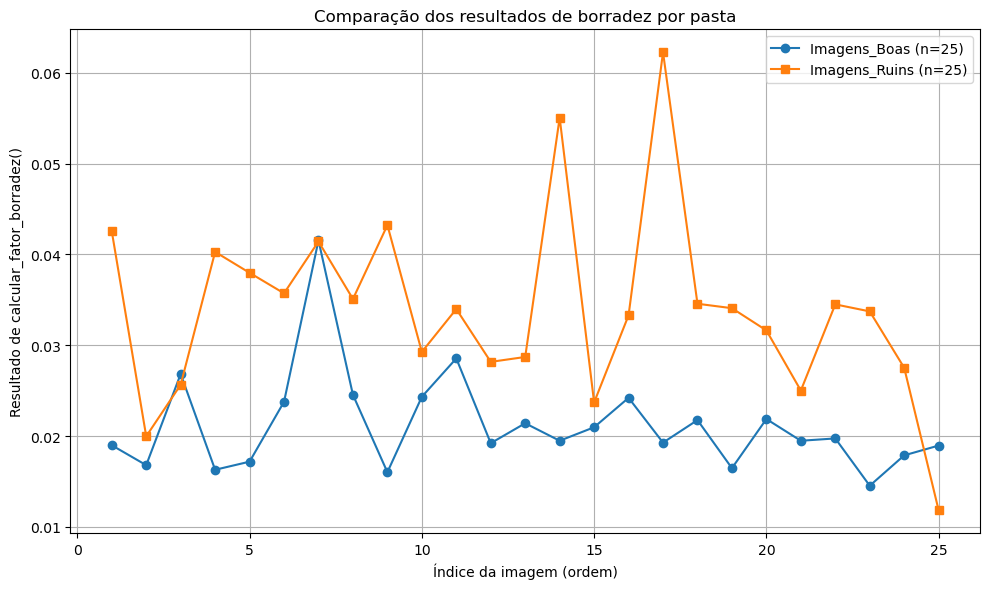

In [ ]:
# Célula principal: percorre duas pastas, aplica `calcular_fator_borradez` em cada imagem e plota resultados
from pathlib import Path
import matplotlib.pyplot as plt

# Extensões aceitas (adicionado .webp porque suas pastas contêm esse formato)
ALLOWED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}


def run_on_folder(folder_path):
    """Percorre uma pasta (recursivamente) e aplica `calcular_fator_borradez` em cada arquivo.

    Retorna duas listas: `results` com os valores (float) e `names` com nomes dos arquivos.
    Arquivos inválidos ou que falharem no processamento são ignorados (e uma mensagem é impressa).
    """
    p = Path(folder_path)
    # rglob para incluir subpastas; filtra por extensão
    files = sorted([f for f in p.rglob('*') if f.suffix.lower() in ALLOWED_EXTS])
    results = []
    names = []
    for f in files:
        try:
            # Chama a função principal de borradez com o caminho do arquivo (mude a chamada de funcao para comparar fft com laplaciano)
            res = calcular_fator_borradez(str(f))
        except Exception as e:
            print(f"Ignorado {f}: {e}")
            continue
        if res is None:
            # Se a função não conseguiu ler/processar o arquivo, avisa e pula
            print(f"Falha ao processar {f}")
            continue
        try:
            results.append(float(res))
        except Exception:
            results.append(res)
        names.append(f.name)
    return results, names


# Pastas relativas à raiz do projeto (substitua se quiser outros caminhos)
from pathlib import Path as _P
project_root = _P('.').resolve()
folder1 = str(project_root / 'Imagens_Boas')
folder2 = str(project_root / 'Imagens_Ruins')

# Executa processamento nas duas pastas
res1, names1 = run_on_folder(folder1)
res2, names2 = run_on_folder(folder2)

# Preparar e plotar
plt.figure(figsize=(10, 6))
plotted = False
# Desenha uma linha por pasta; o eixo x é apenas o índice da imagem na ordem encontrada
if res1:
    plt.plot(range(1, len(res1) + 1), res1, marker='o', label=f"{Path(folder1).name} (n={len(res1)})")
    plotted = True
else:
    print(f"Nenhuma imagem encontrada em: {folder1}")
if res2:
    plt.plot(range(1, len(res2) + 1), res2, marker='s', label=f"{Path(folder2).name} (n={len(res2)})")
    plotted = True
else:
    print(f"Nenhuma imagem encontrada em: {folder2}")

# Rótulos e estilo do gráfico
plt.xlabel('Índice da imagem (ordem)')
plt.ylabel('Resultado de calcular_fator_borradez()')
plt.title('Comparação dos resultados de borradez por pasta')
if plotted:
    plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
